## Next, we can calculate environmental burdens of sectors or entire energy system scenarios using the exported data packages exported in `1_export_packages.ipynb`.
Part of documentation and code is re-used from pathways: https://github.com/polca/pathways, credits to Romain Sacchi and Alvaro Hahn.

We start by instantiating the `Pathways` class, and give it a file path pointing to a datapackage.json of a datapackage or directly the datapackage itself (.zip file).

In [1]:
from pathways import Pathways, __file__
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# for figures
from pathlib import Path
import math
import string
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns


# after discussion with the TRANSIENCE-ITOM team, we decided to exclude obsolete PBRs from the analysis. This is done by setting the following variable to True.
exclude_obsolete_pbr = True

#select the ZIP file where transformation and LCA data are stored;
name_zip_file = r"remind-transience_por.zip"
#name_zip_file = r"remind-transience_example_all.zip"

p = Pathways(
    datapackage=name_zip_file, #better to use ZIP file.
    debug=True # when `debug` is True, a local pathways.log file is created and allows tracking the workflow
)

c:\Users\terlouw_t\.conda\envs\premise_pathways\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
c:\Users\terlouw_t\.conda\envs\premise_pathways\Lib\site-packages\bw2calc\__init__.py:58: UserWarning: No fast sparse solver found
  warnings.warn("No fast sparse solver found")


09:31:57+0200 [warning  ] Can't import `SimaProBlockCSVImporter` - please install `bw2io` with `pip install bw2io[multifunctional]` or install `multifunctional` and `bw_simapro_csv` manually.
Adding REMIND and IMAGE topology using regionalization.py


Log file: C:\Users\terlouw_t\AppData\Local\pylca\pathways\Logs\pathways.log


At this point, you can access all the resources of the `datapackage.Package`, such as the scenario data, for example.
We see that the demand for `technology A`, represented by `product A` (see `.mapping`), is 1'000 kilograms (see `.scenarios.attrs`) each year.

For example, we could check how final energy evolves for transport over the years for the different scenarios in Europe:

We can also see the mapping used in `p.mapping` to map the scenario variables to the LCA datasets.

We can also list the LCIA methods available. Choose climate change as main impact category for now:

In [2]:
met = [mt for mt in p.lcia_methods if 'IPCC 2021 (incl. biogenic CO2' in str(mt) and 'climate change' in str(mt)]
met

['IPCC 2021 (incl. biogenic CO2) no LT - climate change: biogenic (incl. CO2) no LT - global warming potential (GWP100) no LT',
 'IPCC 2021 (incl. biogenic CO2) no LT - climate change: biogenic emissions (incl. CO2) no LT - global warming potential (GWP100) no LT',
 'IPCC 2021 (incl. biogenic CO2) no LT - climate change: biogenic removals (incl. CO2) no LT - global warming potential (GWP100) no LT',
 'IPCC 2021 (incl. biogenic CO2) no LT - climate change: total (incl. biogenic CO2) no LT - global warming potential (GWP100) no LT',
 'IPCC 2021 (incl. biogenic CO2) no LT - climate change: total (incl. biogenic CO2, incl. SLCFs) no LT - global warming potential (GWP100) no LT',
 'IPCC 2021 (incl. biogenic CO2) - climate change: biogenic (incl. CO2) - global warming potential (GWP100)',
 'IPCC 2021 (incl. biogenic CO2) - climate change: biogenic emissions (incl. CO2) - global warming potential (GWP100)',
 'IPCC 2021 (incl. biogenic CO2) - climate change: biogenic removals (incl. CO2) - glo

### We also have a bunch of impact categories related to (critical) material extraction:

In [3]:
[m for m in p.lcia_methods if "metals extraction" in m]

['RELICS - metals extraction - Aluminium',
 'RELICS - metals extraction - Antimony',
 'RELICS - metals extraction - Arsenic',
 'RELICS - metals extraction - Barium',
 'RELICS - metals extraction - Beryllium',
 'RELICS - metals extraction - Boron',
 'RELICS - metals extraction - Cadmium',
 'RELICS - metals extraction - Cerium',
 'RELICS - metals extraction - Chromium',
 'RELICS - metals extraction - Cobalt',
 'RELICS - metals extraction - Copper',
 'RELICS - metals extraction - Dolomite',
 'RELICS - metals extraction - Dysprosium',
 'RELICS - metals extraction - Erbium',
 'RELICS - metals extraction - Europium',
 'RELICS - metals extraction - Gadolinium',
 'RELICS - metals extraction - Gallium',
 'RELICS - metals extraction - Germanium',
 'RELICS - metals extraction - Gold',
 'RELICS - metals extraction - Graphite',
 'RELICS - metals extraction - Hafnium',
 'RELICS - metals extraction - Holmium',
 'RELICS - metals extraction - Indium',
 'RELICS - metals extraction - Iridium',
 'RELICS -

In [4]:
[m for m in p.lcia_methods if "EF v3.1" in m and "climate change - global warming potential (GWP100)" in m]

['EF v3.1 - climate change - global warming potential (GWP100)']

And most importantly, once the `datapackage.Package` is loaded, we can use the method `Pathways.calculate()` to calculate the LCA impacts.

Arguments:

* `methods`: list[str]. LCIA methods to use. To get a complete list of available LCIA methods, call `.lcia_methods`
* `scenarios`: list[str]. List of scenarios you want to calculate the impacts for.
* `variables`: list[str]. List of variables you want to calculate the impacts for (if the demand for them is non-null)
* `regions`: list[str]. Regions for which you want to calculate the impacts, provided the specified variables have a non-null demand in these regions.
* `years`: list[int]. Years for which you want to calculate the impacts.
* `multiprocessing`: bool. Multiprocessing may accelerate the process, as it processes each year in parallel.
* `demand_cutoff`: float. Between 0 and 1. Defines a ratio below which demand values are ignored. The default is 0.001.
* `double_accounting`:list[list[str]]. List of predefined category paths to be adjusted to prevent double counting of activities. Each path indicates the hierarchical categories involved.
* `use_distributions`: bool. Number of iterations to use for Monte Carlo analyses. The default is 0 (i.e., regular analysis).

In the example below, we do so using a stochastic approach (i.e., `use_distributions=500`), leveraging on the uncertainty distributions we defined for each exchange in the datapackage. `bw2calc` and the underlying library `stats_array` generates 500 pseudo-random exchange values and update the technosphere and biosphere matrices between each iteration.

In [5]:
# add some units not defined by pathways itself:
p.units['Mt Crude steel'] = {'kilogram': '1e+9'}
p.units['Mt/year'] = {'kilogram': '1e+9'}
p.units['kt/year'] = {'kilogram': '1e+6'}
p.units['kt/yr'] = {'kilogram': '1e+6'}
p.units

{'PJ/year': {'kilowatt hour': 277800000.0, 'megajoule': '1e+9'},
 'Mtonne/yr': {'kilogram': '1e+9'},
 'Mt/yr': {'kilogram': '1e+9'},
 'million ha': {'square meter': '1e+12'},
 'EJ/yr': {'kilowatt hour': 277800000000.0, 'megajoule': '1e+12'},
 'PJ/yr': {'kilowatt hour': 277800000.0, 'megajoule': '1e+9'},
 'PJ/yr.': {'kilowatt hour': 277800000.0, 'megajoule': '1e+9'},
 'TWh': {'kilowatt hour': '1e+9', 'megajoule': 3600000000.0},
 'bn tkm/yr': {'ton kilometer': '1e+9'},
 'bn pkm/yr': {'passenger kilometer': '1e+9'},
 'Mt CO2/yr': {'kilogram': '1e+9'},
 'Mt': {'kilogram': '1e+9'},
 'billion tkm/yr': {'ton kilometer': '1e+9',
  'kilometer': '1e+9',
  'person kilometer': '1e+9'},
 'billion pkm/yr': {'person kilometer': '1e+9', 'kilometer': '1e+9'},
 'GW/yr': {'unit': 1},
 'million veh': {'unit': '1e6'},
 'TWh/year': {'kilowatt hour': '1e+9', 'megajoule': 3600000000.0},
 'Mt Crude steel': {'kilogram': '1e+9'},
 'Mt/year': {'kilogram': '1e+9'},
 'kt/year': {'kilogram': '1e+6'},
 'kt/yr': {'kil

In [6]:
[v for v in p.scenarios.coords["variables"].values if v.startswith("EXT - ")]

['EXT - 0 - methanol_h2',
 'EXT - 1 - FE_CC_MTO_with_loop',
 'EXT - 1 - FE_CC_gasification',
 'EXT - 1 - FE_CC_waste_pyrolysis',
 'EXT - 1 - FE_MDI',
 'EXT - 1 - FE_PBR',
 'EXT - 1 - FE_PBS',
 'EXT - 1 - FE_PET',
 'EXT - 1 - FE_PLA',
 'EXT - 1 - FE_PMMA',
 'EXT - 1 - FE_PPP',
 'EXT - 1 - FE_PVC',
 'EXT - 1 - FE_nylon',
 'EXT - 1 - FE_polyols',
 'EXT - 1 - FE_polyols_lignin',
 'EXT - 1 - FE_polyols_retrofit',
 'EXT - 1 - ethylene_retrofit_gasoil_cracker',
 'EXT - 1 - ethylene_retrofit_mta_with_loop',
 'EXT - 1 - ethylene_retrofit_naphtha_cracker',
 'EXT - 1 - propylene_trade_import',
 'EXT - 1 - raw_benzene_atmospheric_crude_oil_distillation_default',
 'EXT - 1 - raw_benzene_retrofit_mta_with_loop',
 'EXT - 1 - raw_benzene_retrofit_naphtha_cracker',
 'EXT - 1 - raw_benzene_trade_import',
 'EXT - 1 - raw_para_xylene_atmospheric_crude_oil_distillation_default',
 'EXT - 1 - raw_para_xylene_retrofit_mta_with_loop',
 'EXT - 1 - raw_para_xylene_retrofit_naphtha_cracker',
 'EXT - 1 - raw_para_

In [7]:
[v for v in p.scenarios.coords["variables"].values if v.startswith("EXT - 3 - FE")]

[]

### Now, we can, for example, calculate the results for different scenarios, years, and impact categories for final energy demand of OPEN-PROM:

In [8]:
methods_sel=['IPCC 2021 (incl. biogenic CO2) - climate change: total (incl. biogenic CO2, incl. SLCFs) - global warming potential (GWP100)',
             'EF v3.1 - climate change - global warming potential (GWP100)',
             'EF v3.1 - human toxicity: carcinogenic - comparative toxic unit for human (CTUh)',
            'EF v3.1 - particulate matter formation - impact on human health',
             'EF v3.1 - acidification - accumulated exceedance (AE)',
            'EF v3.1 - ecotoxicity: freshwater - comparative toxic unit for ecosystems (CTUe)',
            'EF v3.1 - eutrophication: terrestrial - accumulated exceedance (AE)',
            'EF v3.1 - material resources: metals/minerals - abiotic depletion potential (ADP): elements (ultimate reserves)',
            'RELICS - metals extraction - Copper',
            'RELICS - metals extraction - Lithium',
            'RELICS - metals extraction - Nickel',
             'RELICS - metals extraction - Cobalt',
            'RELICS - metals extraction - Iridium',
             'RELICS - metals extraction - Dysprosium',
             'RELICS - metals extraction - Palladium',
             'RELICS - metals extraction - Titanium',
            ]


dict_units ={'IPCC 2021 (incl. biogenic CO2) - climate change: total (incl. biogenic CO2, incl. SLCFs) - global warming potential (GWP100)': 'kg CO$_{2}$-eq.',
             'EF v3.1 - climate change - global warming potential (GWP100)': 'kg CO$_{2}$-eq.',
             'EF v3.1 - human toxicity: carcinogenic - comparative toxic unit for human (CTUh)': 'CTUh',
            'EF v3.1 - particulate matter formation - impact on human health': 'disease incidence',
             'EF v3.1 - acidification - accumulated exceedance (AE)': 'mol H+ -eq.',
            'EF v3.1 - ecotoxicity: freshwater - comparative toxic unit for ecosystems (CTUe)': 'CTUe',
            'EF v3.1 - eutrophication: terrestrial - accumulated exceedance (AE)': 'mol N-eq.',
            'EF v3.1 - material resources: metals/minerals - abiotic depletion potential (ADP): elements (ultimate reserves)': 'kg Sb-eq.',
            'RELICS - metals extraction - Copper': 'kilogram',
            'RELICS - metals extraction - Lithium': 'kilogram',
            'RELICS - metals extraction - Nickel': 'kilogram',
             'RELICS - metals extraction - Cobalt': 'kilogram',
            'RELICS - metals extraction - Iridium': 'kilogram',
             'RELICS - metals extraction - Dysprosium': 'kilogram',
             'RELICS - metals extraction - Palladium': 'kilogram',
             'RELICS - metals extraction - Titanium': 'kilogram',
}

In [9]:
p.scenarios.pathway.values.tolist()

['SSP2-PkBudg1000 - fc_nz - CL', 'SSP2-PkBudg1000 - fc_nz - OCE']

In [10]:
nr_models = 1

selected_variables = [
    v
    for v in p.scenarios.coords["variables"].values
    if str(v).startswith(f"EXT - {nr_models} - FE")
]

if exclude_obsolete_pbr:
    selected_variables = [
        v for v in selected_variables
        if str(v).removeprefix(f"EXT - {nr_models} - ") != "FE_PBR"
    ]
selected_variables

['EXT - 1 - FE_CC_MTO_with_loop',
 'EXT - 1 - FE_CC_gasification',
 'EXT - 1 - FE_CC_waste_pyrolysis',
 'EXT - 1 - FE_MDI',
 'EXT - 1 - FE_PBS',
 'EXT - 1 - FE_PET',
 'EXT - 1 - FE_PLA',
 'EXT - 1 - FE_PMMA',
 'EXT - 1 - FE_PPP',
 'EXT - 1 - FE_PVC',
 'EXT - 1 - FE_nylon',
 'EXT - 1 - FE_polyols',
 'EXT - 1 - FE_polyols_lignin',
 'EXT - 1 - FE_polyols_retrofit']

In [11]:
p.calculate(
    methods=methods_sel,
    regions=["NL"],
    scenarios = p.scenarios.pathway.values.tolist(),
    variables= selected_variables,
    years=p.scenarios.coords["year"].values.tolist(),
    multiprocessing=True if len(p.scenarios.pathway.values.tolist()) == 1 else False,
    double_accounting = [["Industry", "Electricity"], ["Industry", "Heat"]],
)

Calculating LCA results for remind...
--- Calculating LCA results for SSP2-PkBudg1000 - fc_nz - CL...
------ Calculating LCA results for 2025...
Missing classification: ['methanol synthesis, hydrogen from electrolysis, CO2 from DAC (por)', 'methanol, unpurified']
Missing classification: ['carbon dioxide, captured, with a sorbent-based direct air capture system, 100ktCO2, with heat pump heat, and grid electricity (por)', 'carbon dioxide, captured']
Missing classification: ['ethylene, via methanol-to-olefins, mass allocation', 'ethylene']
Missing classification: ['p-xylene, via methanol-to-aromatics, mass allocation', 'p-xylene']
Missing classification: ['toluene, via methanol-to-aromatics, mass allocation', 'toluene']
Missing classification: ['benzene, via methanol-to-aromatics, mass allocation', 'benzene']
Missing classification: ['MDI production', 'methylene diphenyl diisocyanate']
Missing classification: ['MDI production, exported', 'methylene diphenyl diisocyanate']
Missing classifi

0% [#] 100% | ETA: 00:00:00
Total time elapsed: 00:01:07


------ Calculating LCA results for 2030...


0% [#] 100% | ETA: 00:00:00
Total time elapsed: 00:01:06


------ Calculating LCA results for 2035...


...

0% [#] 100% | ETA: 00:00:00
Total time elapsed: 00:01:11


------ Calculating LCA results for 2045...


0% [#] 100% | ETA: 00:00:00
Total time elapsed: 00:01:06


------ Calculating LCA results for 2050...


0% [#] 100% | ETA: 00:00:00
Total time elapsed: 00:01:12


We can now access the attribute `.lca_results`, which is an `xarray.DataArray` where the results are stored. While we could directly format it into an `pandas.DataFrame`, it may cause RAM to overflow (because the array is sometimes very large). Instead, we can use `.export_results()`, saving the results as a pandas' DataFrame without zero values.

In [12]:
fp = p.export_results()
# interpolate in-between years
df = pd.read_parquet(fp, engine='pyarrow')
df = df[df["value"]!=0.0]
df = df[~df["value"].isnull()]
df=df.reset_index()
df[['year', 'scenario', 'impact_category','value']].groupby(['year', 'impact_category', 'scenario', ]).sum()

Results exported to results_20261005_095149.gzip


value
year impact_category                                    scenario                                   
2025 EF v3.1 - acidification - accumulated exceedanc... SSP2-PkBudg1000 - fc_nz - CL   1.838118e+07
                                                        SSP2-PkBudg1000 - fc_nz - OCE  1.838245e+07
     EF v3.1 - climate change - global warming poten... SSP2-PkBudg1000 - fc_nz - CL   4.346334e+09
                                                        SSP2-PkBudg1000 - fc_nz - OCE  4.348474e+09
     EF v3.1 - ecotoxicity: freshwater - comparative... SSP2-PkBudg1000 - fc_nz - CL   1.966084e+11
...                                                                                             ...
2050 RELICS - metals extraction - Nickel                SSP2-PkBudg1000 - fc_nz - OCE  4.180528e+06
     RELICS - metals extraction - Palladium             SSP2-PkBudg1000 - fc_nz - CL   5.672229e+00
                                                        SSP2-PkBudg1000 - fc_nz - OCE  1.284166e+01
     RELICS - metals extraction - Titanium              SSP2-PkBudg1000 - fc_nz - CL   1.118364e+06
                                                        SSP2-PkBudg1000 - fc_nz - OCE  1.039704e+06

[192 rows x 1 columns]

In [13]:
df

,index,act_category,variable,year,region,location,model,scenario,impact_category,value
0,0,39920: Sewage sludge,EXT - 1 - FE_CC_MTO_with_loop,2030,NL,CY,remind,SSP2-PkBudg1000 - fc_nz - CL,IPCC 2021 (incl. biogenic CO2) - climate chang...,1.157589e-03
1,1,39920: Sewage sludge,EXT - 1 - FE_CC_MTO_with_loop,2030,NL,CY,remind,SSP2-PkBudg1000 - fc_nz - CL,EF v3.1 - climate change - global warming pote...,8.254843e-04
2,2,39920: Sewage sludge,EXT - 1 - FE_CC_MTO_with_loop,2030,NL,CY,remind,SSP2-PkBudg1000 - fc_nz - CL,EF v3.1 - human toxicity: carcinogenic - compa...,2.097412e-12
3,3,39920: Sewage sludge,EXT - 1 - FE_CC_MTO_with_loop,2030,NL,CY,remind,SSP2-PkBudg1000 - fc_nz - CL,EF v3.1 - particulate matter formation - impac...,1.213931e-10
4,4,39920: Sewage sludge,EXT - 1 - FE_CC_MTO_with_loop,2030,NL,CY,remind,SSP2-PkBudg1000 - fc_nz - CL,EF v3.1 - acidification - accumulated exceedan...,1.834086e-05
...,...,...,...,...,...,...,...,...,...,...
1878996,1878996,undefined,EXT - 1 - FE_polyols_retrofit,2050,NL,NL,remind,SSP2-PkBudg1000 - fc_nz - OCE,EF v3.1 - human toxicity: carcinogenic - compa...,4.222053e-04
1878997,1878997,undefined,EXT - 1 - FE_polyols_retrofit,2050,NL,NL,remind,SSP2-PkBudg1000 - fc_nz - OCE,EF v3.1 - particulate matter formation - impac...,1.156526e-01
1878998,1878998,undefined,EXT - 1 - FE_polyols_retrofit,2050,NL,NL,remind,SSP2-PkBudg1000 - fc_nz - OCE,EF v3.1 - acidification - accumulated exceedan...,2.001620e+04
1878999,1878999,undefined,EXT - 1 - FE_polyols_retrofit,2050,NL,NL,remind,SSP2-PkBudg1000 - fc_nz - OCE,EF v3.1 - ecotoxicity: freshwater - comparativ...,1.318036e+06


### Total impacts for all scenarios and all variables, depending on the impact category

C:\Users\terlouw_t\AppData\Local\Temp\ipykernel_13536\2092593539.py:310: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)
C:\Users\terlouw_t\AppData\Local\Temp\ipykernel_13536\2092593539.py:310: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)
C:\Users\terlouw_t\AppData\Local\Temp\ipykernel_13536\2092593539.py:310: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implemen

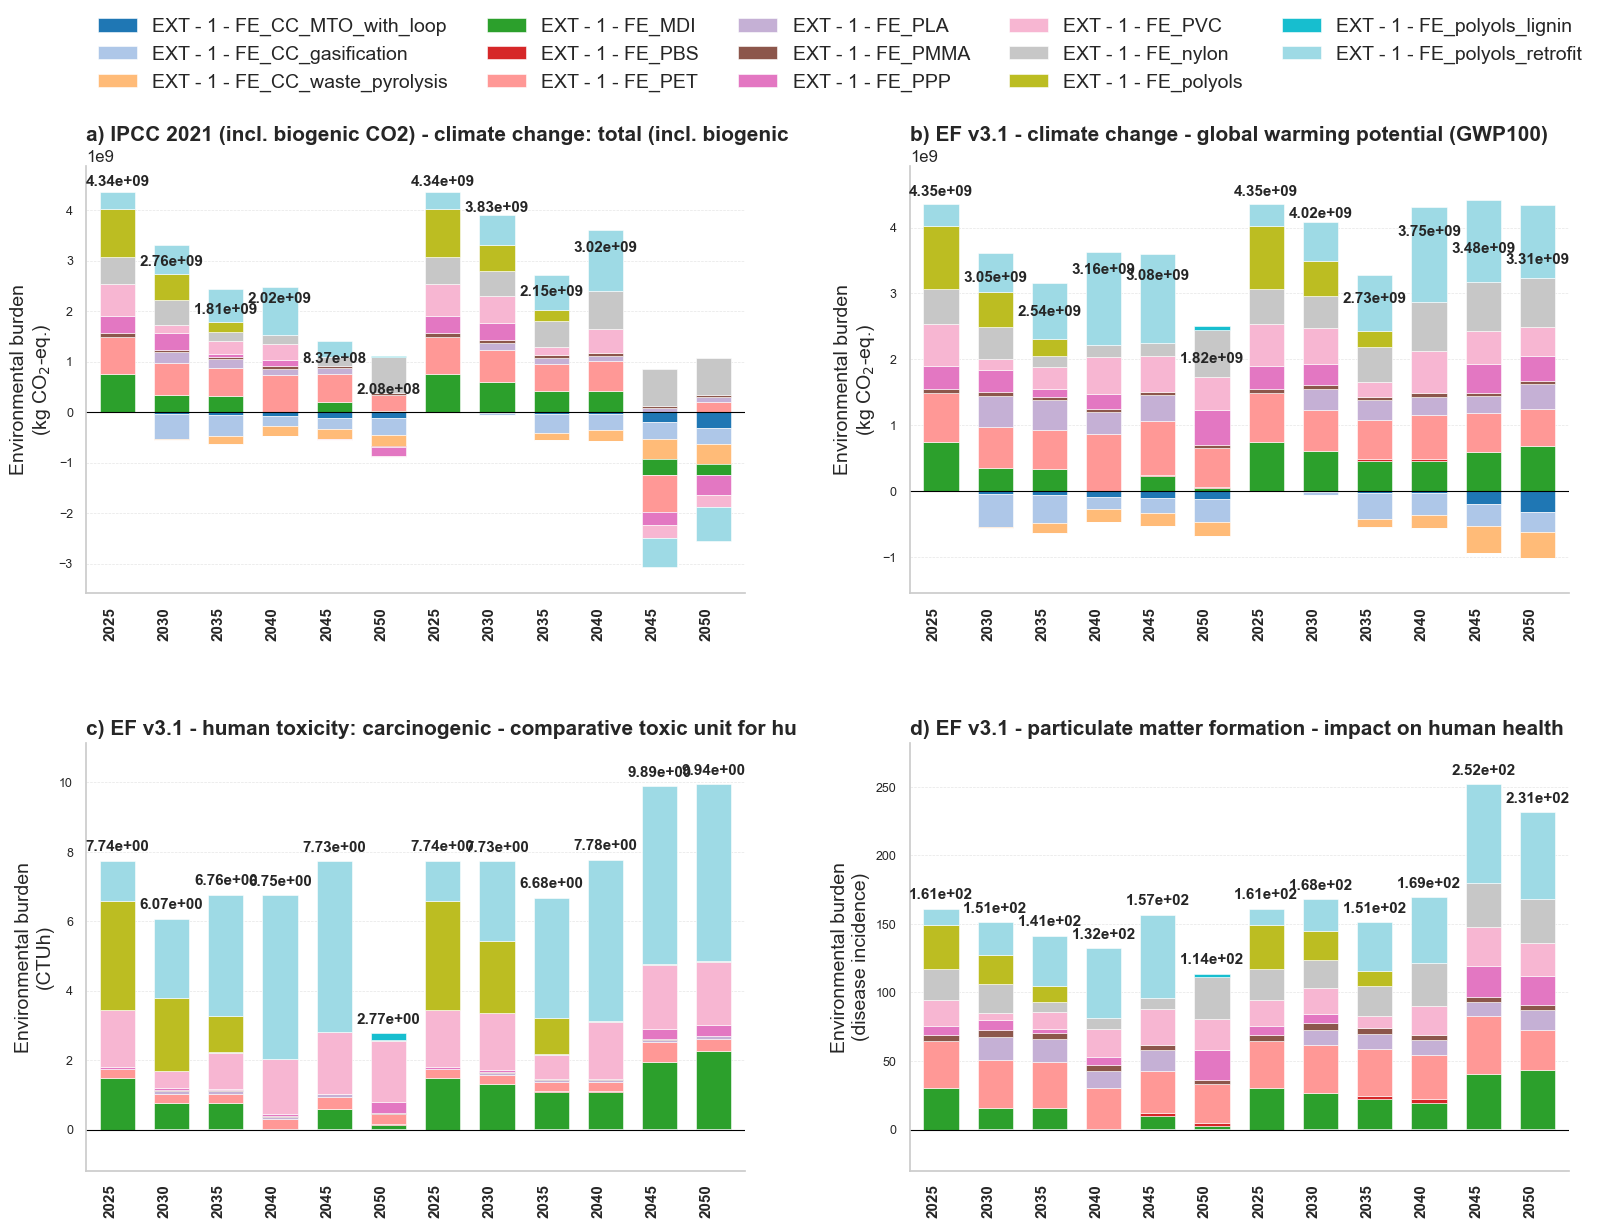

C:\Users\terlouw_t\AppData\Local\Temp\ipykernel_13536\2092593539.py:310: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)
C:\Users\terlouw_t\AppData\Local\Temp\ipykernel_13536\2092593539.py:310: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)
C:\Users\terlouw_t\AppData\Local\Temp\ipykernel_13536\2092593539.py:310: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implemen

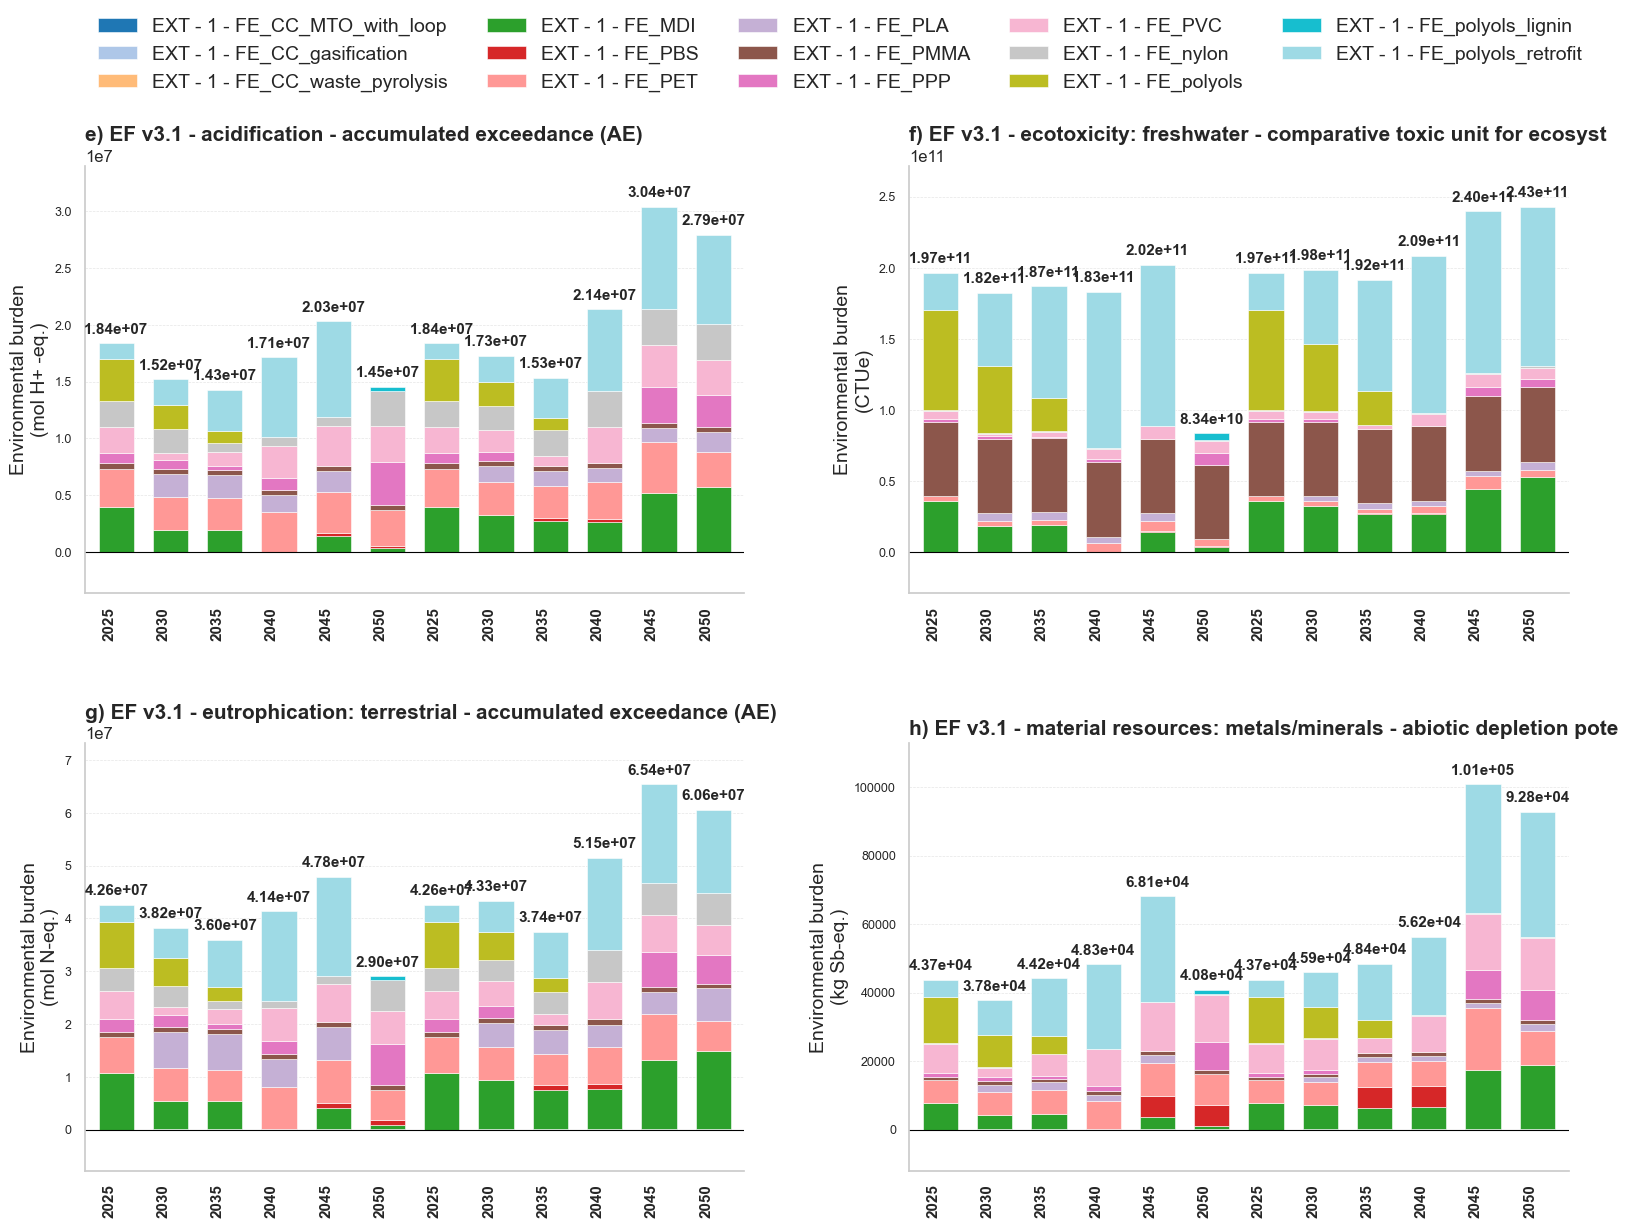

C:\Users\terlouw_t\AppData\Local\Temp\ipykernel_13536\2092593539.py:310: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)
C:\Users\terlouw_t\AppData\Local\Temp\ipykernel_13536\2092593539.py:310: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)
C:\Users\terlouw_t\AppData\Local\Temp\ipykernel_13536\2092593539.py:310: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implemen

OSError: [Errno 22] Invalid argument: 'figs\\impacts_entire_system_port_of_rotterdam_part_3.png'

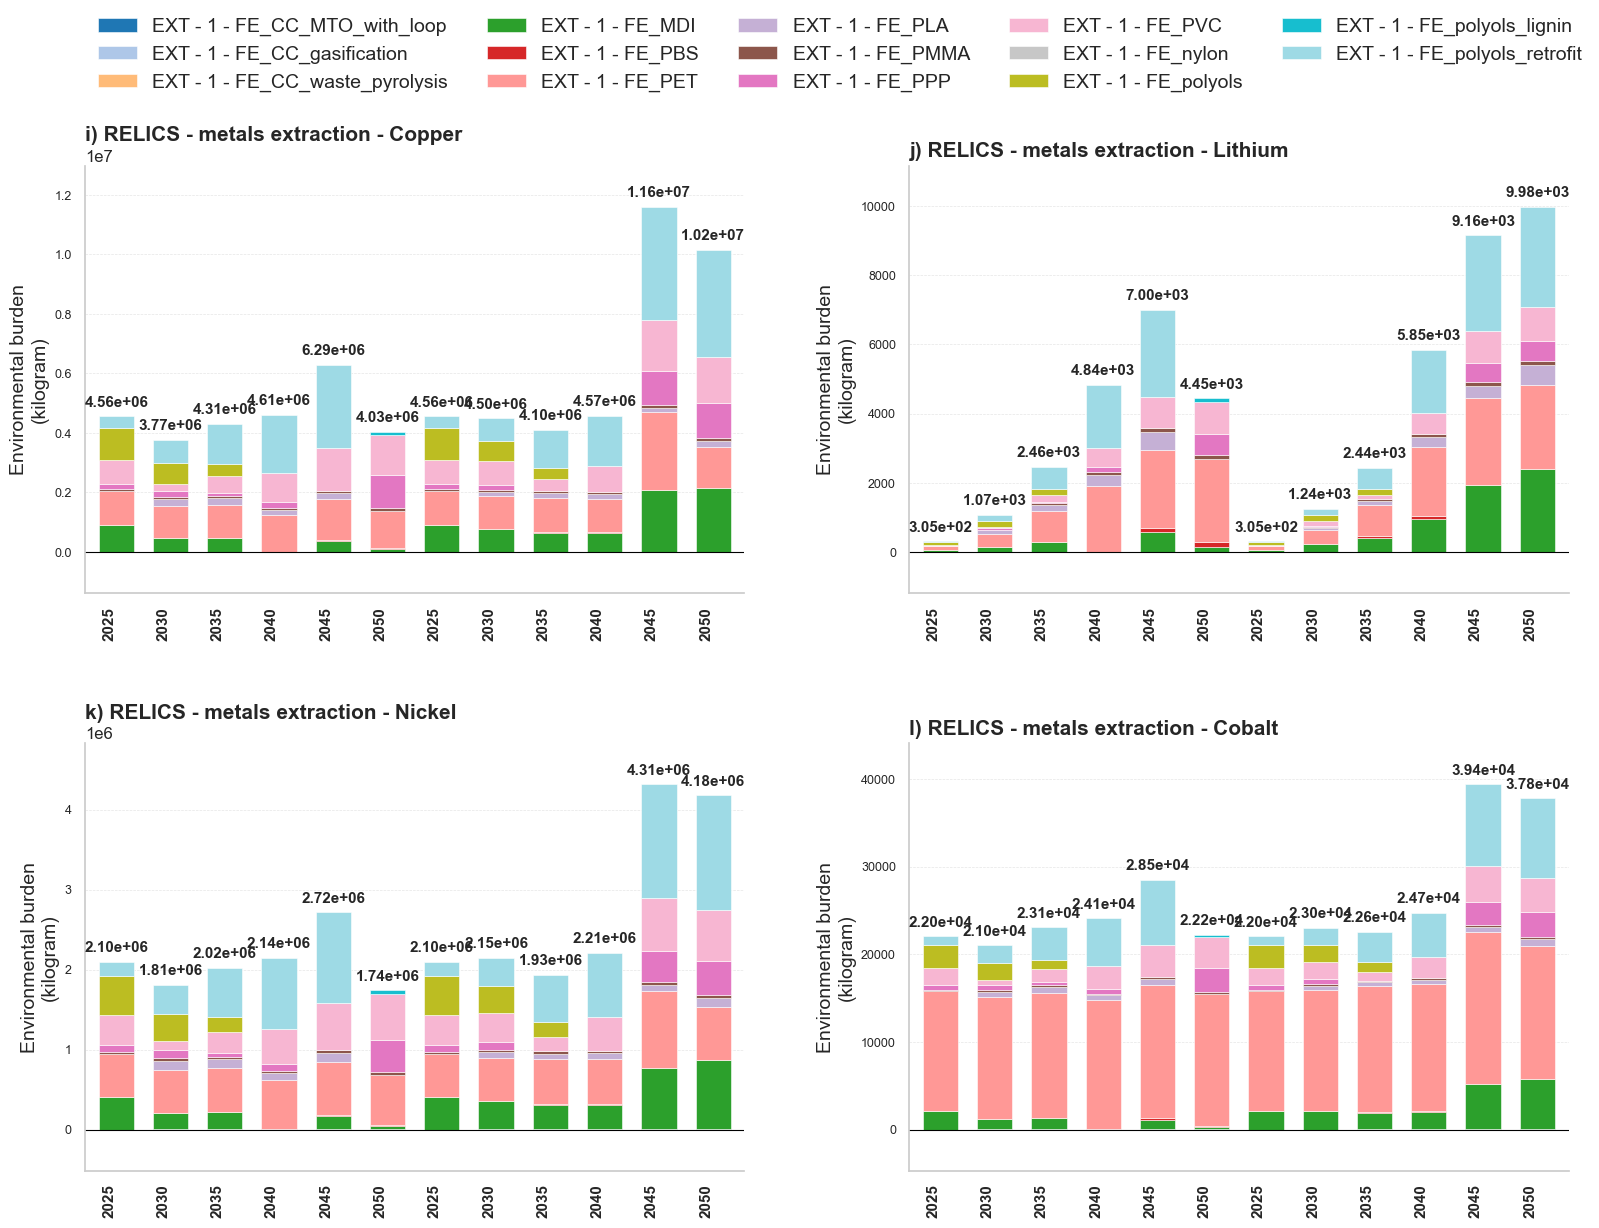

In [14]:
# ===================================================================
# SETTINGS
# ===================================================================

# Column containing the numerical impact results
value_col = "value"

# Output directory
output_dir = Path("figs")
output_dir.mkdir(parents=True, exist_ok=True)

# Set general style and font
sns.set_theme(style="whitegrid")

mpl.rcParams["axes.titlesize"] = 16
mpl.rcParams["axes.labelsize"] = 18
mpl.rcParams["xtick.labelsize"] = 12
mpl.rcParams["ytick.labelsize"] = 12
mpl.rcParams["legend.fontsize"] = 11


# ===================================================================
# RENAMING DICTIONARIES
# ===================================================================

nice_names = {
    "SSP2-NDC - WP1 NPI - CL": "BAU",
    "SSP2-PkBudg1000 - WP1 NetZero - CBAM - fc_nz - CL": "2°C",
}

rename_dict = {
    "FE_cdr_beccs": "CDR BECCS",
    "FE_co2_capture_fossil": "CO$_2$ Capture (Fossil)",
    "FE_industry_process_coal": "Industry (Coal)",
    "FE_industry_process_electricity": "Industry (Electricity)",
    "FE_industry_process_heat": "Industry (Heat)",
    "FE_industry_process_hydrogen": "Industry (Hydrogen)",
    "FE_industry_process_light_fuel_oil": "Industry (LFO)",
    "FE_industry_process_natural_gas": "Industry (Gas)",
    "FE_non_energy_gas": "Non-energy (Gas)",
    "FE_non_energy_liquids": "Non-energy (Liquids)",
    "FE_residential_electricity": "Residential (Electricity)",
    "FE_residential_space_heating_gas": "Residential Heating (Gas)",
    "FE_residential_space_heating_hydrogen": "Residential Heating (Hydrogen)",
    "FE_residential_space_heating_light_fuel_oil": "Residential Heating (LFO)",
    "FE_residential_space_heating_wood": "Residential Heating (Wood)",
    "FE_transportation_electricity": "Transport (Electricity)",
    "FE_transportation_gas": "Transport (Gas)",
    "FE_transportation_hydrogen": "Transport (Hydrogen)",
    "FE_transportation_liquids": "Transport (Liquids)",

    "steel_primary": "Primary steel (BF-BOF)",
    "steel_primary_ccs": "Primary steel (BF-BOF) with CCS",
    "steel_primary_dri_h2": "Primary steel (H$_2$-DRI)",
    "steel_primary_dri_ng": "Primary steel (NG-DRI)",
    "steel_primary_mo_electrolysis": "Primary steel (electrolysis)",
    "steel_secondary": "Secondary steel (iron scrap in EAF)",
}


# ===================================================================
# HELPER FUNCTIONS
# ===================================================================

def clean_variable_name(value):
    """Remove prefixes and unnecessary surrounding spaces."""
    value = str(value).strip()
    value = value.replace("EXT - 3 - ", "")
    return value.strip()


def get_distinct_color_palette(n_colors):
    """Return enough distinct colors for all plotted variables."""
    base = sns.color_palette("colorblind")

    if n_colors <= len(base):
        return base[:n_colors]

    cmap = plt.colormaps.get_cmap("tab20").resampled(n_colors)
    return [cmap(i) for i in range(n_colors)]


def make_excel_sheet_name(name, used_names):
    """
    Convert an impact-category name into a valid and unique Excel sheet name.

    Excel sheet names:
    - may contain at most 31 characters;
    - may not contain []:*?/\\.
    """
    safe_name = re.sub(r"[\[\]:*?/\\]", "_", str(name)).strip()

    if not safe_name:
        safe_name = "impact_category"

    safe_name = safe_name[:31]

    candidate = safe_name
    suffix_number = 1

    while candidate in used_names:
        suffix = f"_{suffix_number}"
        candidate = f"{safe_name[:31 - len(suffix)]}{suffix}"
        suffix_number += 1

    used_names.add(candidate)

    return candidate


# ===================================================================
# CHECK REQUIRED COLUMNS
# ===================================================================

required_columns = {
    "impact_category",
    "scenario",
    "year",
    "variable",
    value_col,
}

missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise KeyError(
        "The input DataFrame is missing the following required columns: "
        f"{sorted(missing_columns)}"
    )


# ===================================================================
# CLEAN AND RENAME VARIABLES
# ===================================================================

df = df.copy()

# Ensure that impact values are numeric
df[value_col] = pd.to_numeric(df[value_col], errors="coerce")

n_missing_values = df[value_col].isna().sum()

if n_missing_values > 0:
    print(
        f"Warning: {n_missing_values} rows contain a missing or non-numeric "
        f"'{value_col}' value. These rows will not contribute to the sums."
    )

df["variable_clean"] = df["variable"].apply(clean_variable_name)

df["variable_renamed"] = (
    df["variable_clean"]
    .map(rename_dict)
    .fillna(df["variable_clean"])
)

renamed_variables = (
    df["variable_renamed"]
    .dropna()
    .drop_duplicates()
    .tolist()
)


# ===================================================================
# CREATE COLOR PALETTE
# ===================================================================

full_palette = get_distinct_color_palette(len(renamed_variables))

variable_colors = {
    variable: full_palette[i]
    for i, variable in enumerate(renamed_variables)
}


# ===================================================================
# CONTAINERS FOR RAW PLOT DATA
# ===================================================================

# Each dictionary entry contains the wide-format data for one impact category.
plot_data_wide = {}

# Each list item contains long-format data for one impact category.
plot_data_long = []


# ===================================================================
# PLOT CONFIGURATION
# ===================================================================

impact_categories = df["impact_category"].dropna().unique().tolist()

ncols = 2
max_subplots_per_fig = 4


# ===================================================================
# CREATE FIGURES AND STORE THE EXACT PLOT DATA
# ===================================================================

for fig_i, start in enumerate(
    range(0, len(impact_categories), max_subplots_per_fig),
    start=1,
):
    impact_chunk = impact_categories[
        start:start + max_subplots_per_fig
    ]

    nrows = math.ceil(len(impact_chunk) / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(16, 6 * nrows),
        sharex=False,
        constrained_layout=False,
        squeeze=False,
    )

    axes = axes.flatten()

    for panel_i, (ax, impact_category) in enumerate(
        zip(axes, impact_chunk)
    ):
        # -----------------------------------------------------------
        # Filter data for this impact category
        # -----------------------------------------------------------

        df_filtered = (
            df.loc[df["impact_category"] == impact_category]
            .sort_values(by=["scenario", "year"])
            .copy()
        )

        # -----------------------------------------------------------
        # Create the table used for the stacked-bar plot
        # -----------------------------------------------------------

        df_pivot = (
            df_filtered
            .pivot_table(
                index=["year", "scenario"],
                columns="variable_renamed",
                values=value_col,
                aggfunc="sum",
                fill_value=0,
            )
        )

        # Sort bars first by scenario and then by year
        df_pivot = df_pivot.sort_index(
            level=["scenario", "year"]
        )

        # Rename scenarios safely within the MultiIndex
        df_pivot = df_pivot.rename(
            index=nice_names,
            level="scenario",
        )

        # Retain the same consistent variable order in all panels
        valid_variables = [
            variable
            for variable in renamed_variables
            if variable in df_pivot.columns
        ]

        if not valid_variables:
            ax.text(
                0.5,
                0.5,
                "No plot data available",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=12,
            )
            ax.set_title(
                f"{string.ascii_lowercase[panel_i]}) "
                f"{str(impact_category)[:70]}",
                fontsize=15,
                fontweight="bold",
                loc="left",
            )
            continue

        # This DataFrame contains exactly the components shown in the plot
        plot_df = df_pivot.loc[:, valid_variables].copy()

        # Add the net total represented by each stacked bar
        plot_df["Total"] = plot_df[valid_variables].sum(axis=1)

        # -----------------------------------------------------------
        # Store wide-format raw plot data
        # -----------------------------------------------------------

        plot_data_wide[impact_category] = plot_df.copy()

        # -----------------------------------------------------------
        # Store long-format raw plot data
        # -----------------------------------------------------------

        impact_long_df = (
            plot_df[valid_variables]
            .rename_axis(
                index=["year", "scenario"],
                columns="contributor",
            )
            .stack(dropna=False)
            .rename(value_col)
            .reset_index()
        )

        impact_long_df["impact_category"] = impact_category
        impact_long_df["unit"] = dict_units.get(
            impact_category,
            "",
        )

        # Add the total for the corresponding scenario-year bar
        totals_for_merge = (
            plot_df[["Total"]]
            .reset_index()
            .rename(columns={"Total": "total"})
        )

        impact_long_df = impact_long_df.merge(
            totals_for_merge,
            on=["year", "scenario"],
            how="left",
            validate="many_to_one",
        )

        # Set a clear and convenient column order
        impact_long_df = impact_long_df[
            [
                "impact_category",
                "unit",
                "scenario",
                "year",
                "contributor",
                value_col,
                "total",
            ]
        ]

        plot_data_long.append(impact_long_df)

        # -----------------------------------------------------------
        # Create stacked-bar plot
        # -----------------------------------------------------------

        plot_df[valid_variables].plot(
            kind="bar",
            stacked=True,
            legend=False,
            color=[
                variable_colors[variable]
                for variable in valid_variables
            ],
            ax=ax,
            width=0.65,
            edgecolor="white",
            linewidth=0.4,
        )

        totals = plot_df["Total"]

        # Add total labels above positive bars
        positive_totals = totals[totals > 1]

        if not positive_totals.empty:
            total_label_offset = 0.02 * max(
                abs(totals.min()),
                abs(totals.max()),
                1,
            )

            for bar_i, total in enumerate(totals):
                if total > 1:
                    ax.text(
                        bar_i,
                        total + total_label_offset,
                        f"{total:.2e}",
                        ha="center",
                        va="bottom",
                        fontsize=11,
                        fontweight="bold",
                    )

        # -----------------------------------------------------------
        # Format subplot
        # -----------------------------------------------------------

        global_panel_i = start + panel_i

        if global_panel_i < len(string.ascii_lowercase):
            panel_label = string.ascii_lowercase[global_panel_i]
        else:
            panel_label = str(global_panel_i + 1)

        ax.set_title(
            f"{panel_label}) {str(impact_category)[:70]}",
            fontsize=15,
            fontweight="bold",
            loc="left",
        )

        ax.set_ylabel(
            "Environmental burden\n"
            f"({dict_units.get(impact_category, '')})",
            fontsize=14,
        )

        ax.set_xlabel("")

        years = plot_df.index.get_level_values("year")

        ax.set_xticks(range(len(years)))
        ax.set_xticklabels(
            years,
            rotation=90,
            ha="right",
        )

        ax.tick_params(
            axis="x",
            rotation=90,
            labelsize=11,
        )

        for label in ax.get_xticklabels():
            label.set_fontweight("bold")

        ax.tick_params(
            axis="y",
            labelsize=9,
        )

        ax.axhline(
            0,
            color="black",
            linewidth=0.8,
        )

        ax.grid(
            axis="y",
            linestyle="--",
            linewidth=0.5,
            alpha=0.5,
        )

        ax.grid(
            axis="x",
            visible=False,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # -----------------------------------------------------------
        # Set y-axis limits
        #
        # Positive and negative stacks must be considered separately.
        # Simply summing all contributions can underestimate the actual
        # visible extent when both positive and negative values occur.
        # -----------------------------------------------------------

        positive_stack = (
            plot_df[valid_variables]
            .clip(lower=0)
            .sum(axis=1)
        )

        negative_stack = (
            plot_df[valid_variables]
            .clip(upper=0)
            .sum(axis=1)
        )

        y_min = min(0, negative_stack.min())
        y_max = max(0, positive_stack.max())

        y_scale = max(
            abs(y_min),
            abs(y_max),
            1e-12,
        )

        y_margin = 0.12 * y_scale

        ax.set_ylim(
            y_min - y_margin,
            y_max + y_margin,
        )

    # Remove unused axes
    for ax in axes[len(impact_chunk):]:
        ax.remove()

    # ---------------------------------------------------------------
    # Create one shared legend for the figure
    # ---------------------------------------------------------------

    plotted_axes = [
        ax
        for ax in axes[:len(impact_chunk)]
        if ax.has_data()
    ]

    if plotted_axes:
        handles, labels = plotted_axes[0].get_legend_handles_labels()

        if handles:
            fig.legend(
                handles,
                labels,
                loc="upper center",
                bbox_to_anchor=(0.53, 1.03),
                ncols=5,
                frameon=False,
                fontsize=14,
            )

    fig.tight_layout(
        rect=[0, 0, 1, 0.94]
    )

    fig.subplots_adjust(
        hspace=0.35,
        wspace=0.25,
    )

    figure_path = (
        output_dir
        / f"impacts_entire_system_port_of_rotterdam_part_{fig_i}.png"
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.2,
    )

    plt.show()
    plt.close(fig)


# ===================================================================
# COMBINE ALL STORED LONG-FORM DATA
# ===================================================================

if not plot_data_long:
    raise ValueError(
        "No plot data were created. Check the impact categories, "
        "variables, and numerical value column."
    )

plot_data_long_df = pd.concat(
    plot_data_long,
    ignore_index=True,
)

plot_data_long_df = (
    plot_data_long_df
    .sort_values(
        by=[
            "impact_category",
            "scenario",
            "year",
            "contributor",
        ]
    )
    .reset_index(drop=True)
)


# ===================================================================
# CREATE A SEPARATE TOTALS TABLE
# ===================================================================

plot_totals_df = (
    plot_data_long_df[
        [
            "impact_category",
            "unit",
            "scenario",
            "year",
            "total",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        by=[
            "impact_category",
            "scenario",
            "year",
        ]
    )
    .reset_index(drop=True)
)


# ===================================================================
# EXPORT RAW PLOT DATA
# ===================================================================

csv_path = (
    output_dir
    / "impacts_entire_system_port_of_rotterdam_raw_plot_data.csv"
)

parquet_path = (
    output_dir
    / "impacts_entire_system_port_of_rotterdam_raw_plot_data.parquet"
)

excel_path = (
    output_dir
    / "impacts_entire_system_port_of_rotterdam_raw_plot_data.xlsx"
)


# CSV: convenient for sharing and use in most software
plot_data_long_df.to_csv(
    csv_path,
    index=False,
)


# Parquet: efficient and preserves data types
try:
    plot_data_long_df.to_parquet(
        parquet_path,
        index=False,
    )
    parquet_exported = True

except ImportError:
    parquet_exported = False
    print(
        "Parquet export was skipped because neither 'pyarrow' nor "
        "'fastparquet' is installed."
    )


# Excel:
# - all_data_long: all individual stacked-bar contributions
# - totals: the total value for every bar
# - one wide-format sheet for each impact category
with pd.ExcelWriter(
    excel_path,
    engine="openpyxl",
) as writer:
    plot_data_long_df.to_excel(
        writer,
        sheet_name="all_data_long",
        index=False,
    )

    plot_totals_df.to_excel(
        writer,
        sheet_name="totals",
        index=False,
    )

    used_sheet_names = {
        "all_data_long",
        "totals",
    }

    for impact_category, impact_df in plot_data_wide.items():
        sheet_name = make_excel_sheet_name(
            impact_category,
            used_sheet_names,
        )

        wide_export_df = (
            impact_df
            .reset_index()
        )

        wide_export_df.insert(
            0,
            "unit",
            dict_units.get(impact_category, ""),
        )

        wide_export_df.insert(
            0,
            "impact_category",
            impact_category,
        )

        wide_export_df.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False,
        )


# ===================================================================
# REPORT EXPORTED FILES
# ===================================================================

print("\nPlotting and raw-data export completed.")

print(f"\nCSV file:\n{csv_path.resolve()}")

if parquet_exported:
    print(f"\nParquet file:\n{parquet_path.resolve()}")

print(f"\nExcel file:\n{excel_path.resolve()}")

print(
    f"\nStored {len(plot_data_long_df):,} individual plot-data rows "
    f"for {len(plot_data_wide):,} impact categories."
)

# Display a small preview in the notebook
display(plot_data_long_df.head(20))

## Plot some inputs

In [ ]:
variables = [
    v for v in p.scenarios.coords["variables"].values
    if str(v).startswith("EXT - 1 - FE")
    and "FE_CC_" not in str(v)
]

# Select all variables
df_vars = (
    p.scenarios
    .sel(variables=variables)
    .to_dataframe()
    .reset_index()
)
df_vars

,model,pathway,variables,region,year,value
0,remind,SSP2-PkBudg1000 - fc_nz - OCE,EXT - 1 - FE_MDI,NL,2025,271.411513
1,remind,SSP2-PkBudg1000 - fc_nz - OCE,EXT - 1 - FE_MDI,NL,2030,244.910987
2,remind,SSP2-PkBudg1000 - fc_nz - OCE,EXT - 1 - FE_MDI,NL,2035,201.106481
3,remind,SSP2-PkBudg1000 - fc_nz - OCE,EXT - 1 - FE_MDI,NL,2040,199.566577
4,remind,SSP2-PkBudg1000 - fc_nz - OCE,EXT - 1 - FE_MDI,NL,2045,314.076923
...,...,...,...,...,...,...
61,remind,SSP2-PkBudg1000 - fc_nz - OCE,EXT - 1 - FE_polyols_retrofit,NL,2030,294.8
62,remind,SSP2-PkBudg1000 - fc_nz - OCE,EXT - 1 - FE_polyols_retrofit,NL,2035,442.2
63,remind,SSP2-PkBudg1000 - fc_nz - OCE,EXT - 1 - FE_polyols_retrofit,NL,2040,589.6
64,remind,SSP2-PkBudg1000 - fc_nz - OCE,EXT - 1 - FE_polyols_retrofit,NL,2045,589.6


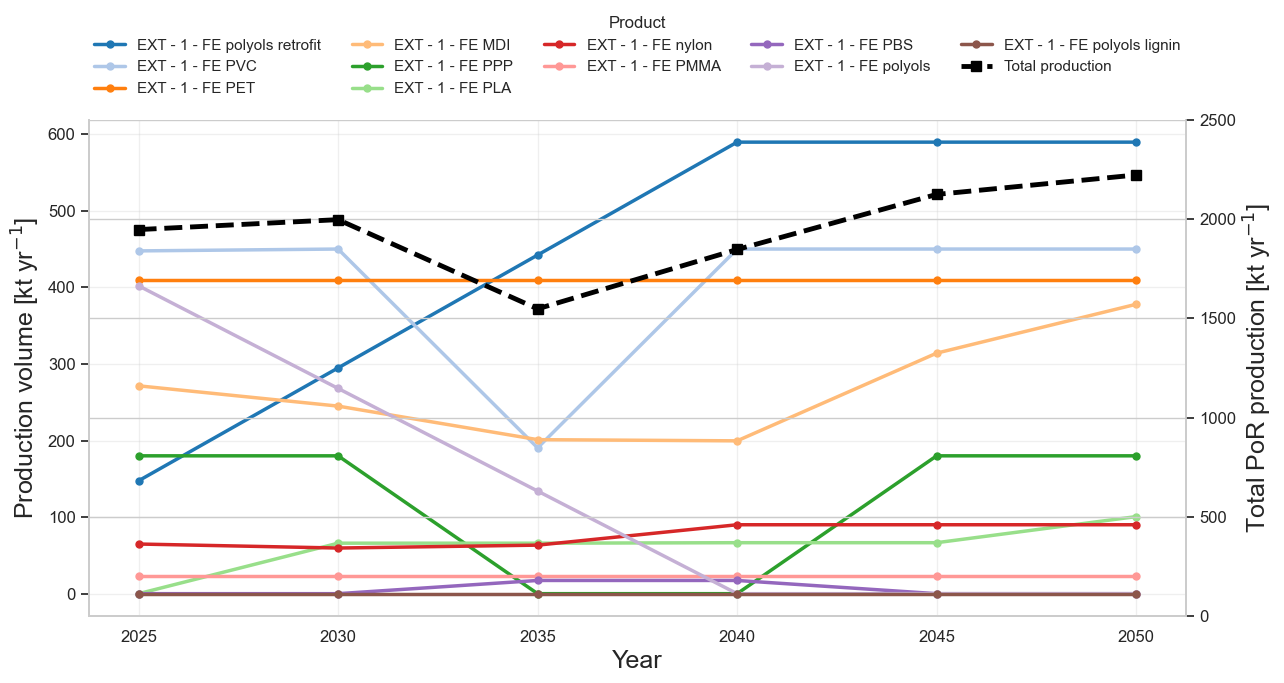

In [ ]:
plot_df = df_vars.copy()

# Clean names
plot_df["variable_short"] = (
    plot_df["variables"]
    .str.replace(r"EXT - 1 - FE\|", "", regex=True)
    .str.replace("_", " ")
)

# Total production per year
total_df = (
    plot_df.groupby("year", as_index=False)["value"]
    .sum()
    .rename(columns={"value": "total_production"})
)

# Sort variables by final-year value
order = (
    plot_df.sort_values("year")
    .groupby("variable_short")["value"]
    .last()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(13, 7))

# Product lines
cmap = plt.get_cmap("tab20")
colors = [cmap(i) for i in range(len(order))]

for i, var in enumerate(order):
    subset = plot_df[plot_df["variable_short"] == var]

    ax.plot(
        subset["year"],
        subset["value"],
        label=var,
        color=colors[i],
        linewidth=2.5,
        marker="o",
        markersize=5,
    )

# Secondary axis with total production
ax2 = ax.twinx()

ax2.plot(
    total_df["year"],
    total_df["total_production"],
    color="black",
    linewidth=3.5,
    linestyle="--",
    marker="s",
    markersize=7,
    label="Total production",
)

# Labels
ax.set_xlabel("Year")
ax.set_ylabel("Production volume [kt yr$^{-1}$]")
ax2.set_ylabel("Total PoR production [kt yr$^{-1}$]")


ax2.set_ylim(0, 2500)

# Grid only from primary axis
ax.grid(True, alpha=0.3)

# Remove top spines
ax.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

# Combine legends
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    handles1 + handles2,
    labels1 + labels2,
    title="Product",
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=5,
    frameon=False,
)

plt.tight_layout()
plt.show()

In [ ]:
fp = p.export_results()
# interpolate in-between years
df = pd.read_parquet(fp, engine='pyarrow')
df = df[df["value"]!=0.0]
df = df[~df["value"].isnull()]
df=df.reset_index()
df[['year', 'scenario', 'impact_category','value']].groupby(['year', 'impact_category', 'scenario', ]).sum()

Results exported to results_20261002_164944.gzip


value
year impact_category                                    scenario                                   
2025 EF v3.1 - acidification - accumulated exceedanc... SSP2-PkBudg1000 - fc_nz - OCE  1.838154e+07
     EF v3.1 - climate change - global warming poten... SSP2-PkBudg1000 - fc_nz - OCE  4.361997e+09
     EF v3.1 - ecotoxicity: freshwater - comparative... SSP2-PkBudg1000 - fc_nz - OCE  1.965942e+11
     EF v3.1 - eutrophication: terrestrial - accumul... SSP2-PkBudg1000 - fc_nz - OCE  4.258322e+07
     EF v3.1 - human toxicity: carcinogenic - compar... SSP2-PkBudg1000 - fc_nz - OCE  7.735707e+00
...                                                                                             ...
2050 RELICS - metals extraction - Iridium               SSP2-PkBudg1000 - fc_nz - OCE  6.279394e+01
     RELICS - metals extraction - Lithium               SSP2-PkBudg1000 - fc_nz - OCE  9.975227e+03
     RELICS - metals extraction - Nickel                SSP2-PkBudg1000 - fc_nz - OCE  4.176654e+06
     RELICS - metals extraction - Palladium             SSP2-PkBudg1000 - fc_nz - OCE  1.283972e+01
     RELICS - metals extraction - Titanium              SSP2-PkBudg1000 - fc_nz - OCE  1.039489e+06

[96 rows x 1 columns]

In [ ]:
df_vars

,model,pathway,variables,region,year,value
0,remind,SSP2-PkBudg1000 - fc_nz - OCE,EXT - 1 - FE_MDI,NL,2025,271.411513
1,remind,SSP2-PkBudg1000 - fc_nz - OCE,EXT - 1 - FE_MDI,NL,2030,244.910987
2,remind,SSP2-PkBudg1000 - fc_nz - OCE,EXT - 1 - FE_MDI,NL,2035,201.106481
3,remind,SSP2-PkBudg1000 - fc_nz - OCE,EXT - 1 - FE_MDI,NL,2040,199.566577
4,remind,SSP2-PkBudg1000 - fc_nz - OCE,EXT - 1 - FE_MDI,NL,2045,314.076923
...,...,...,...,...,...,...
61,remind,SSP2-PkBudg1000 - fc_nz - OCE,EXT - 1 - FE_polyols_retrofit,NL,2030,294.8
62,remind,SSP2-PkBudg1000 - fc_nz - OCE,EXT - 1 - FE_polyols_retrofit,NL,2035,442.2
63,remind,SSP2-PkBudg1000 - fc_nz - OCE,EXT - 1 - FE_polyols_retrofit,NL,2040,589.6
64,remind,SSP2-PkBudg1000 - fc_nz - OCE,EXT - 1 - FE_polyols_retrofit,NL,2045,589.6


C:\Users\terlouw_t\AppData\Local\Temp\ipykernel_10084\718499951.py:139: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", n_colors)
C:\Users\terlouw_t\AppData\Local\Temp\ipykernel_10084\718499951.py:188: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(0)
C:\Users\terlouw_t\AppData\Local\Temp\ipykernel_10084\718499951.py:188: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silen

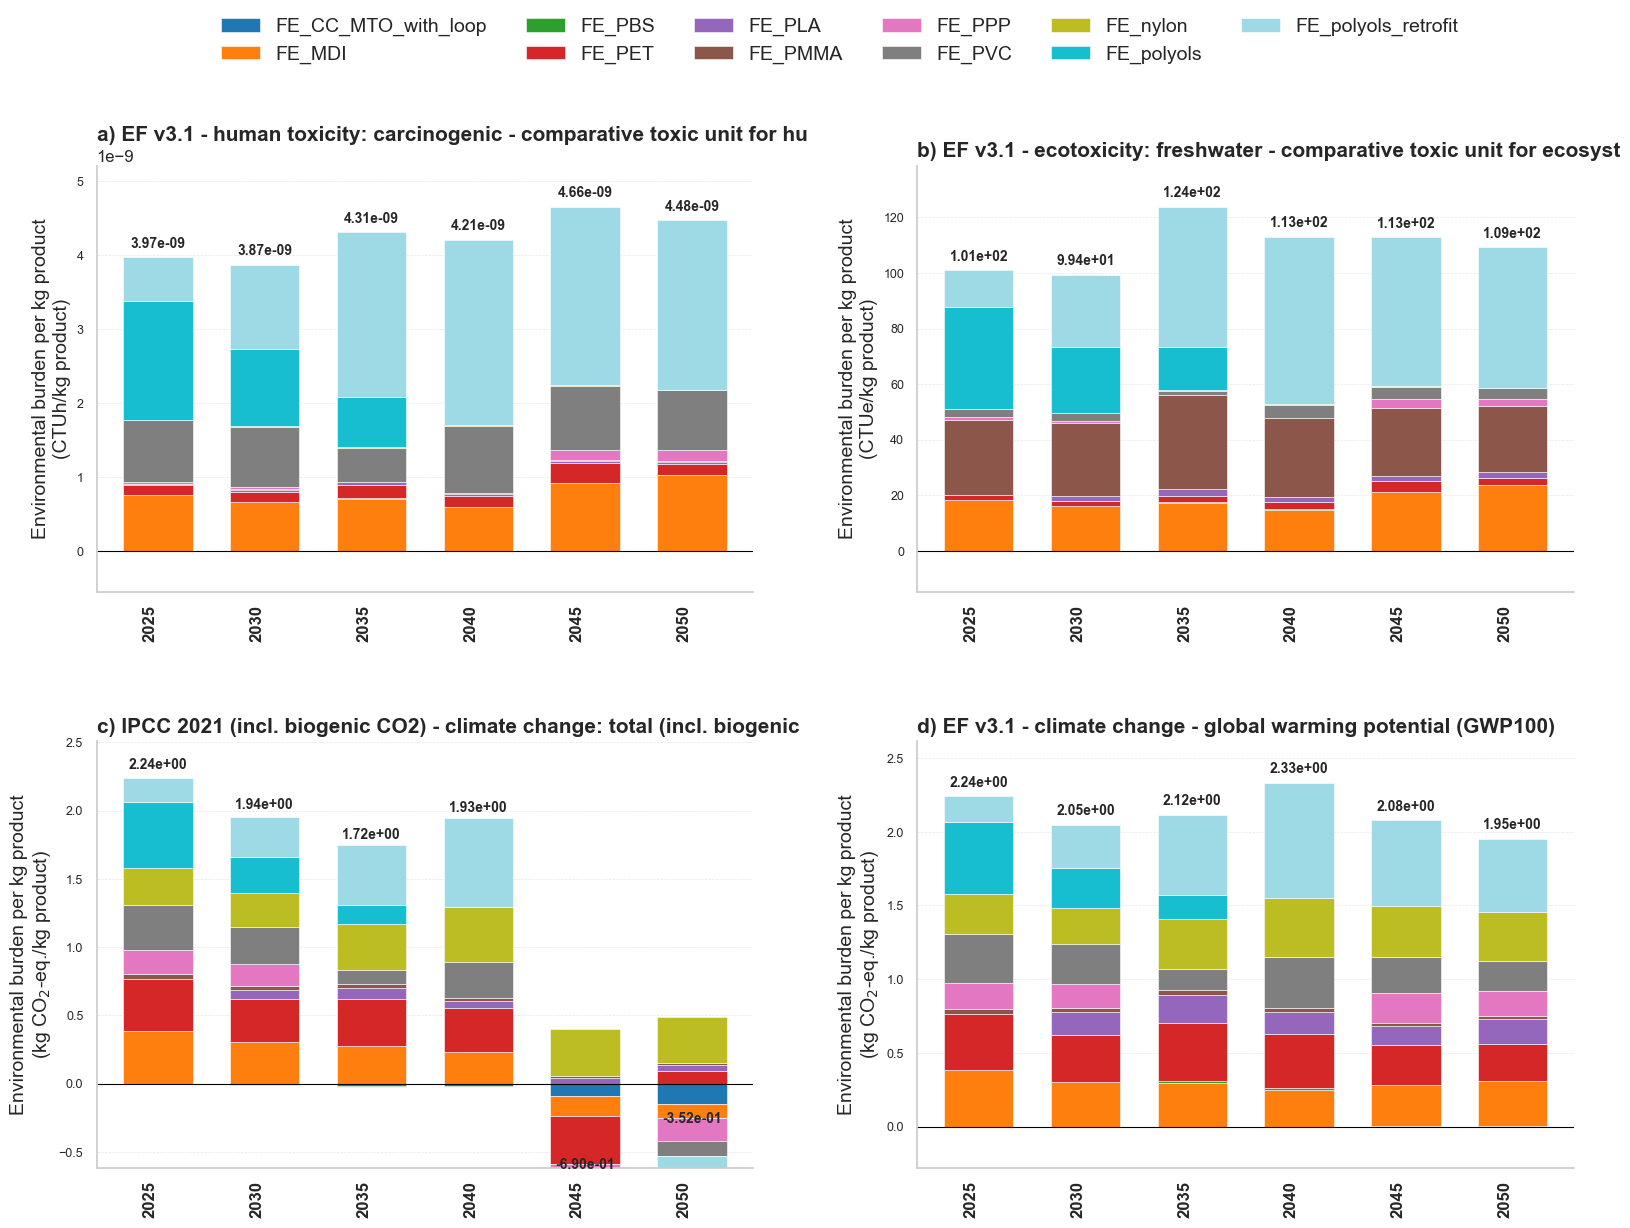

C:\Users\terlouw_t\AppData\Local\Temp\ipykernel_10084\718499951.py:188: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(0)
C:\Users\terlouw_t\AppData\Local\Temp\ipykernel_10084\718499951.py:188: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(0)
C:\Users\terlouw_t\AppData\Local\Temp\ipykernel_10084\718499951.py:188: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('futu

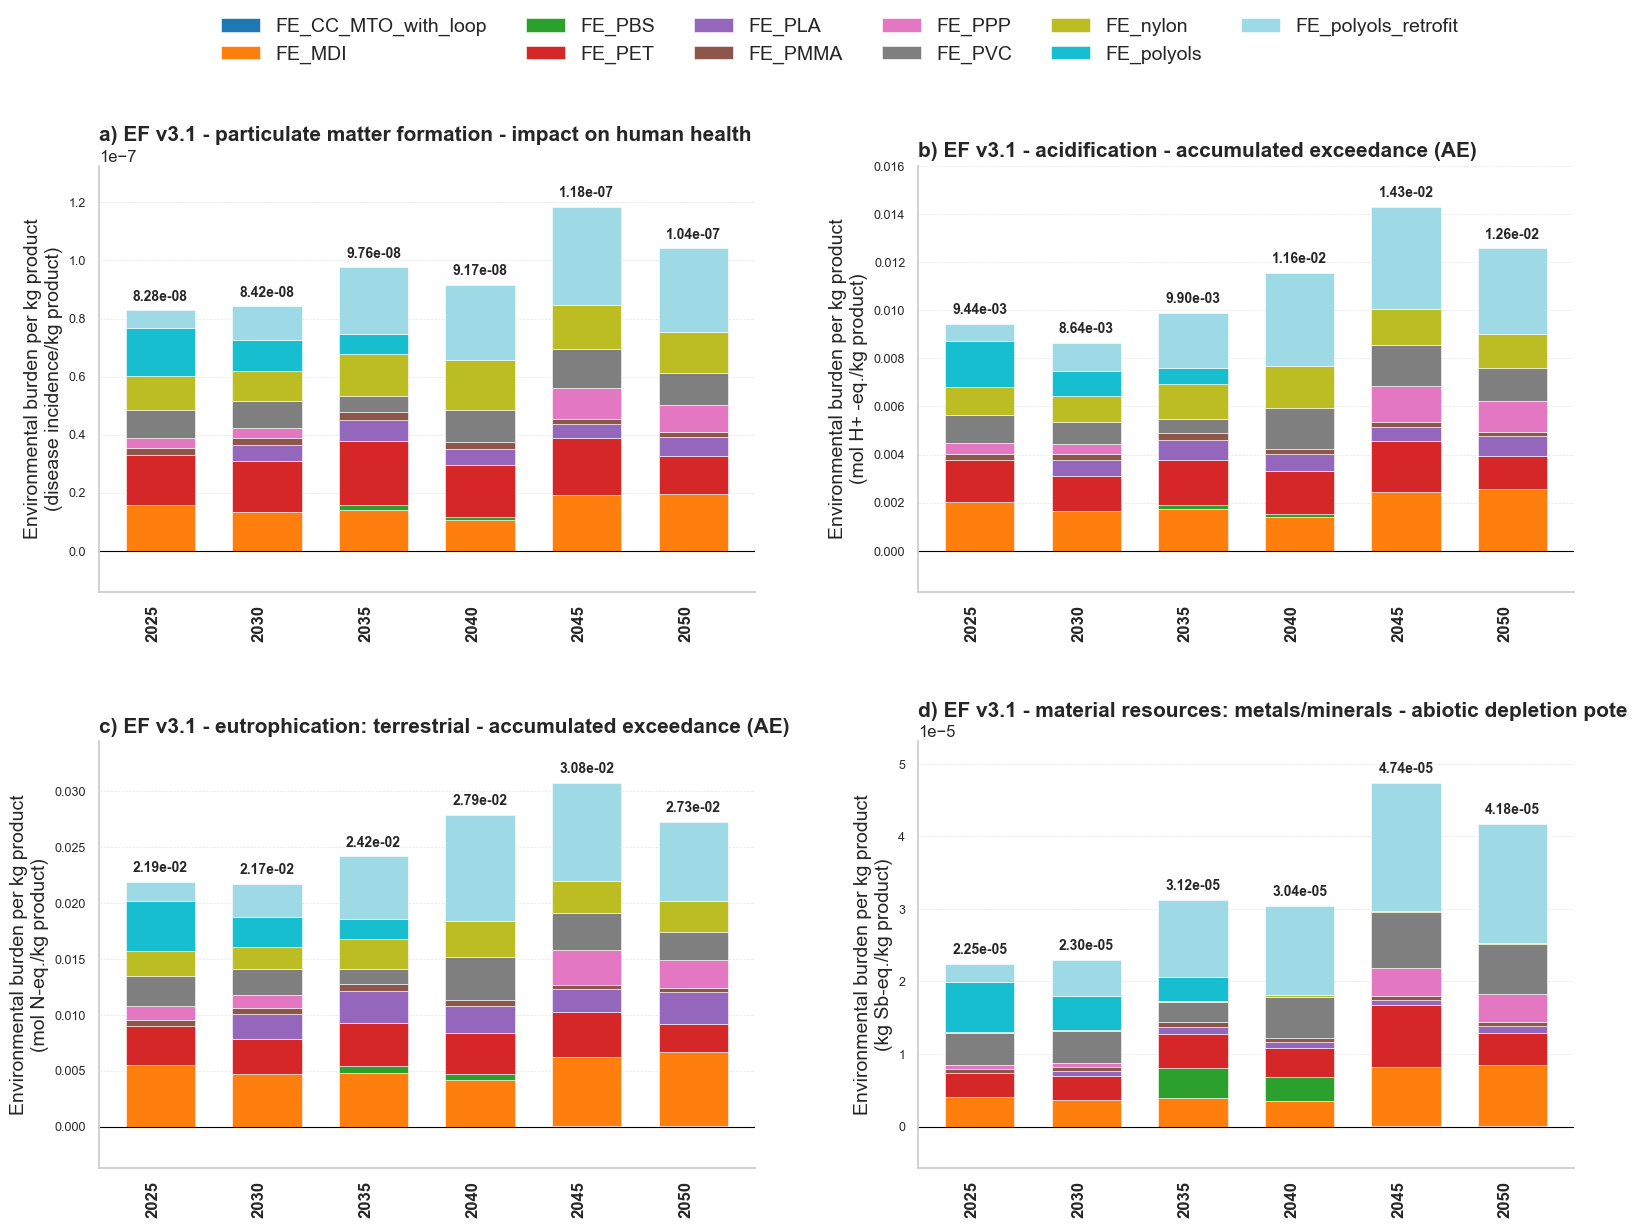

C:\Users\terlouw_t\AppData\Local\Temp\ipykernel_10084\718499951.py:188: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(0)
C:\Users\terlouw_t\AppData\Local\Temp\ipykernel_10084\718499951.py:188: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(0)
C:\Users\terlouw_t\AppData\Local\Temp\ipykernel_10084\718499951.py:188: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('futu

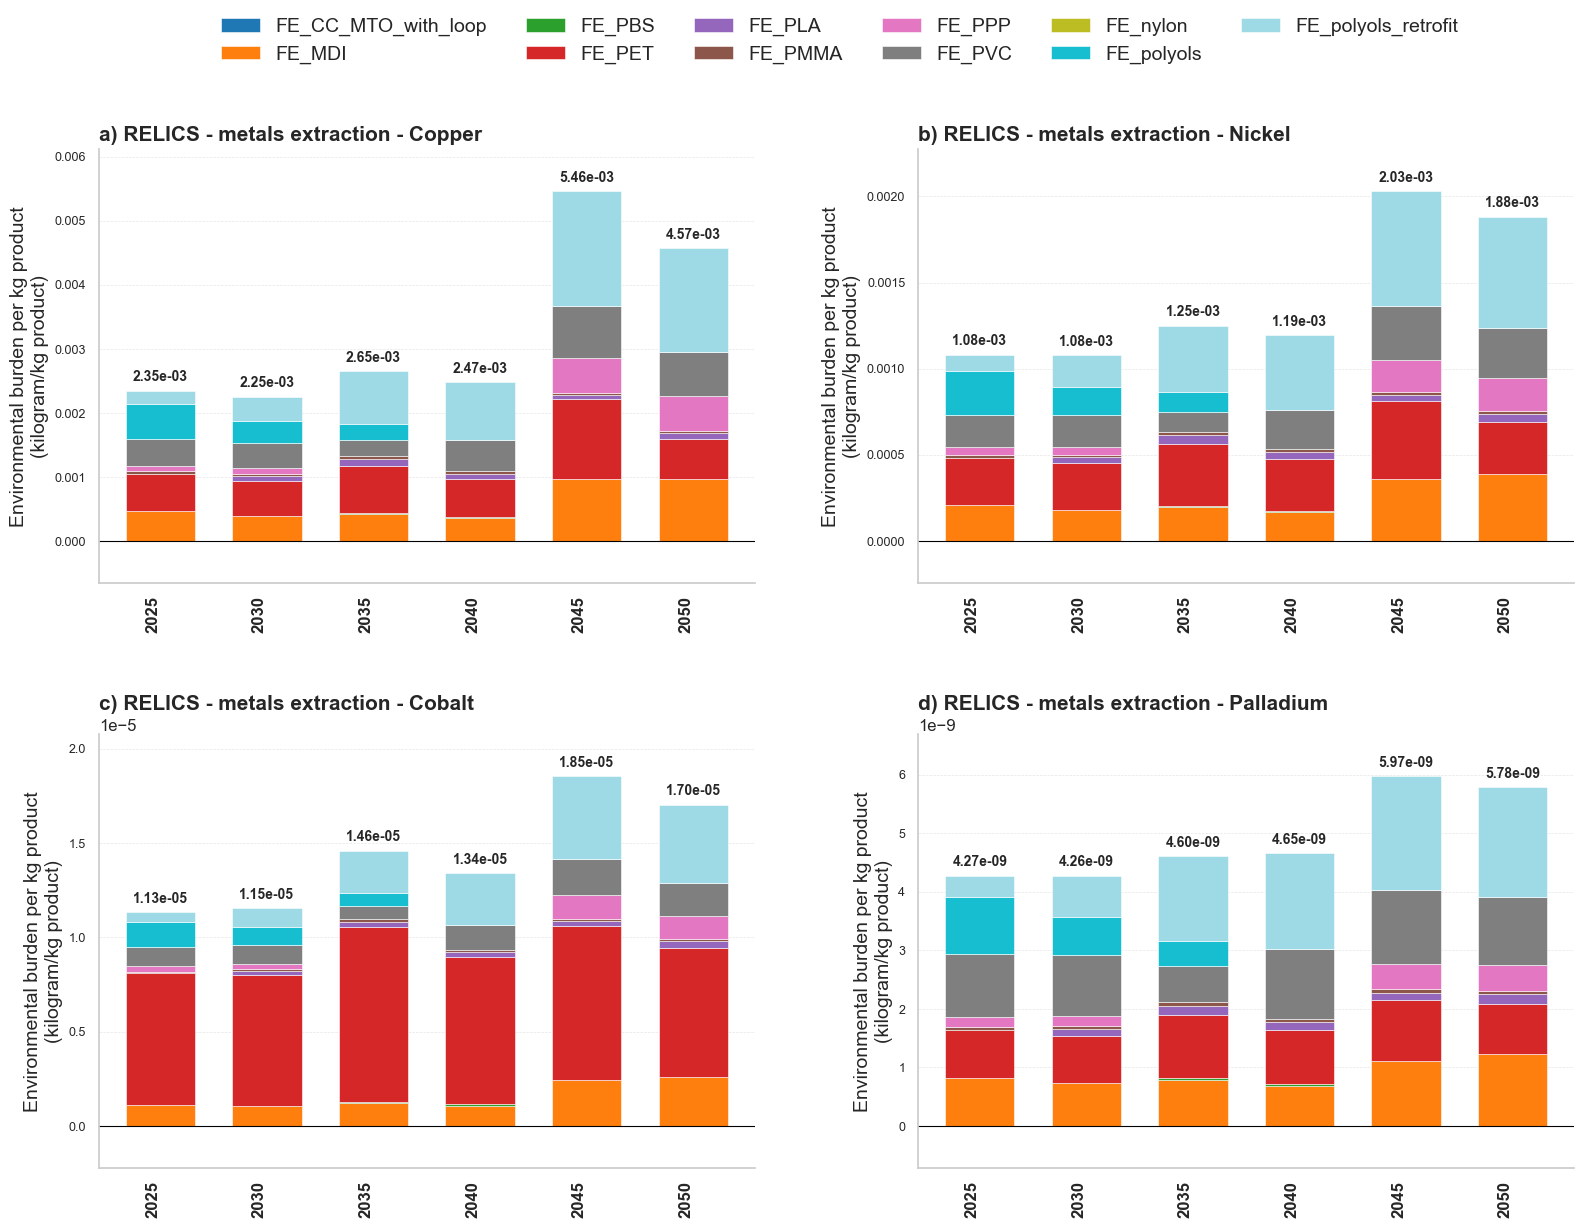

C:\Users\terlouw_t\AppData\Local\Temp\ipykernel_10084\718499951.py:188: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(0)
C:\Users\terlouw_t\AppData\Local\Temp\ipykernel_10084\718499951.py:188: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(0)
C:\Users\terlouw_t\AppData\Local\Temp\ipykernel_10084\718499951.py:188: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('futu

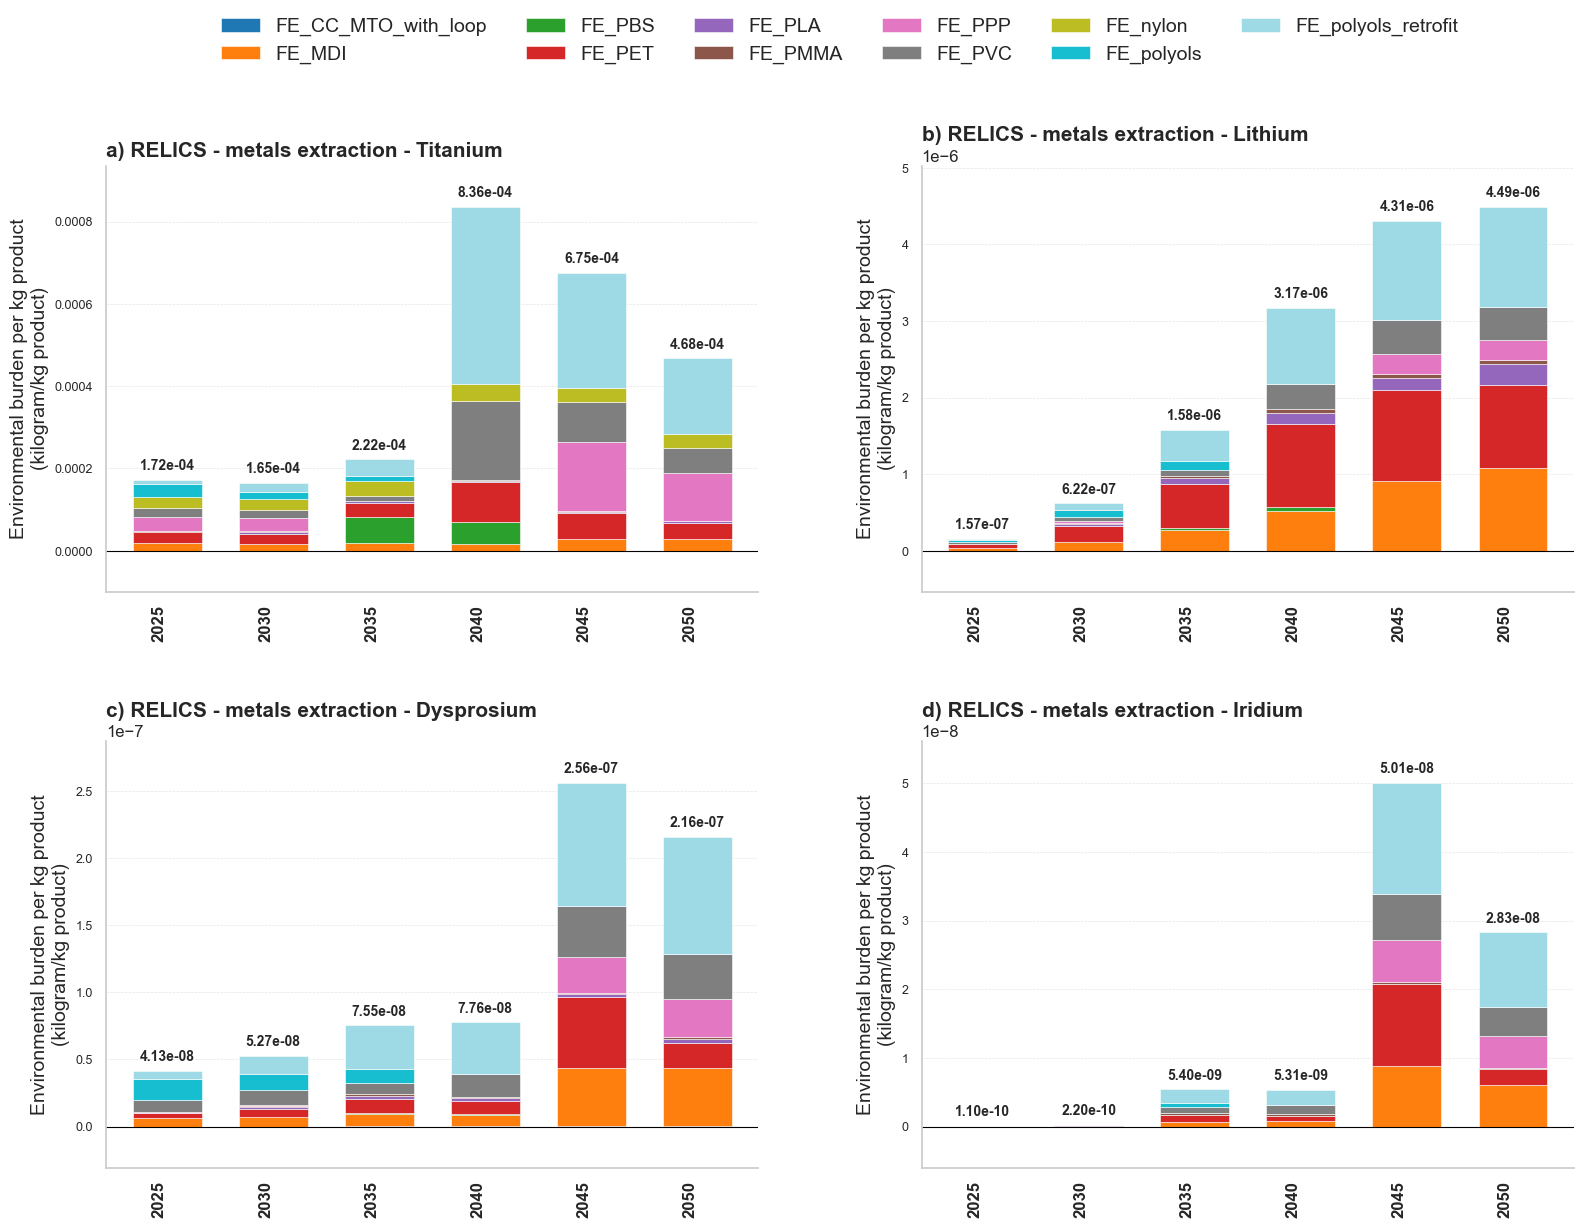

In [ ]:
import math
import string
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# ----------------------------
# Settings
# ----------------------------

value_col = "value"

sns.set_theme(style="whitegrid")

mpl.rcParams["axes.titlesize"] = 16
mpl.rcParams["axes.labelsize"] = 18
mpl.rcParams["xtick.labelsize"] = 12
mpl.rcParams["ytick.labelsize"] = 12
mpl.rcParams["legend.fontsize"] = 11

nice_names = {
    "SSP2-NDC - WP1 NPI - CL": "BAU",
    "SSP2-PkBudg1000 - WP1 NetZero - CBAM - fc_nz - CL": "2°C",
}

rename_dict = {
    "FE_cdr_beccs": "CDR BECCS",
    "FE_co2_capture_fossil": "CO$_2$ Capture (Fossil)",
    "FE_industry_process_coal": "Industry (Coal)",
    "FE_industry_process_electricity": "Industry (Electricity)",
    "FE_industry_process_heat": "Industry (Heat)",
    "FE_industry_process_hydrogen": "Industry (Hydrogen)",
    "FE_industry_process_light_fuel_oil": "Industry (LFO)",
    "FE_industry_process_natural_gas": "Industry (Gas)",
    "FE_non_energy_gas": "Non-energy (Gas)",
    "FE_non_energy_liquids": "Non-energy (Liquids)",
    "FE_residential_electricity": "Residential (Electricity)",
    "FE_residential_space_heating_gas": "Residential Heating (Gas)",
    "FE_residential_space_heating_hydrogen": "Residential Heating (Hydrogen)",
    "FE_residential_space_heating_light_fuel_oil": "Residential Heating (LFO)",
    "FE_residential_space_heating_wood": "Residential Heating (Wood)",
    "FE_transportation_electricity": "Transport (Electricity)",
    "FE_transportation_gas": "Transport (Gas)",
    "FE_transportation_hydrogen": "Transport (Hydrogen)",
    "FE_transportation_liquids": "Transport (Liquids)",
    "steel_primary": "Primary steel (BF-BOF)",
    "steel_primary_ccs": "Primary steel (BF-BOF) with CCS",
    "steel_primary_dri_h2": "Primary steel (H$_2$-DRI)",
    "steel_primary_dri_ng": "Primary steel (NG-DRI)",
    "steel_primary_mo_electrolysis": "Primary steel (electrolysis)",
    "steel_secondary": "Secondary steel (iron scrap in EAF)",
}

# ----------------------------
# Clean names
# ----------------------------

def clean_for_mapping(s):
    return (
        str(s)
        .strip()
        .replace("EXT - 1 - ", "")
    )

df = df.copy()
df_vars = df_vars.copy()

df["variable_clean"] = df["variable"].apply(clean_for_mapping)
df["variable_renamed"] = df["variable_clean"].map(rename_dict).fillna(df["variable_clean"])

# ----------------------------
# Prepare production volumes
# ----------------------------

production_df = df_vars.copy()

production_df["scenario"] = production_df["pathway"]
production_df["variable_clean"] = production_df["variables"].apply(clean_for_mapping)

total_production = (
    production_df
    .groupby(["year", "scenario"], as_index=False)["value"]
    .sum()
    .rename(columns={"value": "total_production_kt"})
)

total_production["total_production_kg"] = total_production["total_production_kt"] * 1e6

# ----------------------------
# Merge production into impact results
# ----------------------------

# ----------------------------
# Merge production into impact results
# ----------------------------

df = df.drop(
    columns=[
        "total_production_kt",
        "total_production_kg",
        "total_production_kt_x",
        "total_production_kt_y",
        "total_production_kg_x",
        "total_production_kg_y",
        "value_per_kg_product",
    ],
    errors="ignore",
)

df = df.merge(
    total_production[["year", "scenario", "total_production_kg"]],
    on=["year", "scenario"],
    how="left",
)

df["value_per_kg_product"] = df[value_col] / df["total_production_kg"]

# Check missing matches
missing = df["total_production_kg"].isna().sum()
if missing > 0:
    print(f"Warning: {missing} rows have no matching production volume.")
    print(df.loc[df["total_production_kg"].isna(), ["year", "scenario"]].drop_duplicates())

df["value_per_kg_product"] = df[value_col] / df["total_production_kg"]

# ----------------------------
# Colours
# ----------------------------

renamed_variables = df["variable_renamed"].drop_duplicates().tolist()

def get_distinct_color_palette(n_colors):
    base = sns.color_palette("colorblind")
    if n_colors <= len(base):
        return base[:n_colors]

    cmap = plt.cm.get_cmap("tab20", n_colors)
    return [cmap(i) for i in range(n_colors)]

full_palette = get_distinct_color_palette(len(renamed_variables))

variable_colors = {
    var: full_palette[i]
    for i, var in enumerate(renamed_variables)
}

# ----------------------------
# Plot
# ----------------------------

impact_categories = list(df["impact_category"].unique())

ncols = 2
max_subplots_per_fig = 4

for fig_i, start in enumerate(range(0, len(impact_categories), max_subplots_per_fig), start=1):

    impact_chunk = impact_categories[start:start + max_subplots_per_fig]
    nrows = math.ceil(len(impact_chunk) / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(16, 6 * nrows),
        sharex=False,
        constrained_layout=False,
    )

    axes = np.atleast_1d(axes).flatten()

    for panel_i, (ax, impact_category) in enumerate(zip(axes, impact_chunk)):

        df_filtered = (
            df[df["impact_category"] == impact_category]
            .sort_values(by=["scenario", "year"])
        )

        df_pivot = (
            df_filtered
            .pivot_table(
                index=["year", "scenario"],
                columns="variable_renamed",
                values="value_per_kg_product",
                aggfunc="sum",
            )
            .fillna(0)
        )

        df_pivot = df_pivot.sort_index(level=["scenario", "year"])

        df_pivot.index = df_pivot.index.set_levels(
            df_pivot.index.levels[1].to_series().replace(nice_names),
            level="scenario",
        )

        valid_variables = [v for v in renamed_variables if v in df_pivot.columns]

        df_pivot[valid_variables].plot(
            kind="bar",
            stacked=True,
            legend=False,
            color=[variable_colors[v] for v in valid_variables],
            ax=ax,
            width=0.65,
            edgecolor="white",
            linewidth=0.4,
        )

        totals = df_pivot[valid_variables].sum(axis=1)

        for idx, total in enumerate(totals):
            if total != 0:
                ax.text(
                    idx,
                    total + 0.02 * totals.max(),
                    f"{total:.2e}",
                    ha="center",
                    va="bottom",
                    fontsize=10,
                    fontweight="bold",
                )

        global_panel_i = panel_i

        ax.set_title(
            f"{string.ascii_lowercase[global_panel_i]}) {impact_category[:70]}",
            fontsize=15,
            fontweight="bold",
            loc="left",
        )

        ax.set_ylabel(
            f"Environmental burden per kg product\n({dict_units[impact_category]}/kg product)",
            fontsize=14,
        )
        ax.set_xlabel("")

        years = [year for year, scenario in df_pivot.index]

        ax.set_xticks(range(len(years)))
        ax.set_xticklabels(years, rotation=90, ha="right")
        
        for label in ax.get_xticklabels():
            label.set_fontweight("bold")

        ax.tick_params(axis="y", labelsize=9)

        ax.axhline(0, color="black", linewidth=0.8)
        ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
        ax.grid(axis="x", visible=False)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        y_min = min(0, df_pivot[valid_variables].min().min())
        y_max = totals.max()
        y_margin = 0.12 * max(abs(y_min), abs(y_max))

        ax.set_ylim(y_min - y_margin, y_max + y_margin)

    for ax in axes[len(impact_chunk):]:
        ax.remove()

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.53, 1.03),
        ncols=6,
        frameon=False,
        fontsize=14,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.subplots_adjust(hspace=0.35, wspace=0.25)

    plt.savefig(
        f"figs/impacts_per_kg_product_port_of_rotterdam_part_{fig_i}.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.2,
    )

    plt.show()

In [ ]:
total_production["total_production_kg"]

0    1946223121.943737
1    1996230316.779397
2     1547288368.30658
3     1845981722.34918
4    2123231590.742023
5    2221115416.201486
Name: total_production_kg, dtype: object